# Firm behavior through time

This notebook reads the complete quarterly `Model` snapshots directly. Its primary view is a firm-by-quarter heatmap: persistent firm IDs form the rows, quarters form the columns, and color represents one selected behavior.

The synchronized aggregate plot helps relate coordinated firm-level changes to emergent model outcomes. These are descriptions of BeforeIT simulations, not empirical causal claims about real economies.

In [1]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Markdown
using Plots
using Statistics
using TOML

default(; linewidth = 2, framestyle = :box, legend = :best)

trace_root = let
    candidates = unique(normpath.([
        @__DIR__,
        pwd(),
        joinpath(pwd(), "dba-studies", "machine-learning", "explanation-traces"),
    ]))
    matches = filter(path -> isfile(joinpath(path, "experiment.toml")), candidates)
    isempty(matches) && error("Could not locate explanation-traces/experiment.toml")
    first(matches)
end

include(joinpath(trace_root, "src", "explanation_traces.jl"))
using .ExplanationTraces

specification = TOML.parsefile(joinpath(trace_root, "experiment.toml"))
experiment_id = specification["experiment"]["id"]
experiment_directory = joinpath(trace_root, "experiments", experiment_id)
runs_path = joinpath(experiment_directory, "runs.csv")
isfile(runs_path) || error("Missing experiment. Run run_experiment.jl first: $runs_path")
runs = CSV.read(runs_path, DataFrame)
(; trace_root, experiment_id, experiment_directory)

(trace_root = "/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces", experiment_id = "credit-constraint-quarterly-states-v1", experiment_directory = "/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1")

## Select and validate a run

The default is the first successful baseline seed. Change `selected_run_id` to inspect another row from the run inventory.

In [2]:
successful_baselines = sort(runs[(runs.success .== true) .& (runs.role .== "baseline"), :], :seed)
isempty(successful_baselines) && error("No successful baseline run found")
selected_run_id = first(successful_baselines.run_id)
selected_run = only(eachrow(filter(:run_id => ==(selected_run_id), runs)))
run_directory = joinpath(experiment_directory, selected_run.snapshot_directory)
paths = snapshot_paths(run_directory)

expected_quarters = collect(0:Int(selected_run.horizon))
quarters = [load_snapshot(path)["quarter"] for path in paths]
checks = DataFrame(
    check = ["run succeeded", "all quarterly files exist", "quarters are contiguous"],
    passed = [selected_run.success, length(paths) == selected_run.horizon + 1, quarters == expected_quarters],
)
all(checks.passed) || error("Snapshot integrity checks failed")
(; selected_run_id, checks)

(selected_run_id = "baseline-seed-4101", checks = 3×2 DataFrame
 Row │ check                      passed 
     │ String                     Bool   
─────┼───────────────────────────────────
   1 │ run succeeded                true
   2 │ all quarterly files exist    true
   3 │ quarters are contiguous      true)

In [3]:
initial_model = load_snapshot(first(paths))["model"]
firm_count = length(initial_model.firms.ID)
available_firm_fields = [
    field for field in fieldnames(typeof(initial_model.firms))
    if getfield(initial_model.firms, field) isa AbstractVector &&
       length(getfield(initial_model.firms, field)) == firm_count
]
DataFrame(field = string.(available_firm_fields))

Row,field
,String
1,ID
2,G_i
3,alpha_bar_i
4,beta_i
5,kappa_i
6,w_i
7,w_bar_i
8,delta_i
9,tau_Y_i


## Build the firm-by-quarter matrix

`measure` may be any aligned firm vector shown above, or `:credit_gap`. `:signed_log1p` compresses large values while preserving signs; use `:raw` for levels or `:within_firm_zscore` to emphasize each firm's deviations from its own history.

In [4]:
measure = :Y_i
scale = :signed_log1p

firm_data = firm_panel(paths)
firm_state = firm_matrix(firm_data, measure)

function transform_values(values, mode)
    transformed = copy(values)
    if mode == :raw
        return transformed, "raw"
    elseif mode == :signed_log1p
        observed = isfinite.(transformed)
        transformed[observed] .= sign.(transformed[observed]) .* log1p.(abs.(transformed[observed]))
        return transformed, "signed log(1 + |x|)"
    elseif mode == :within_firm_zscore
        for row in axes(transformed, 1)
            observed = filter(isfinite, transformed[row, :])
            center = isempty(observed) ? 0.0 : mean(observed)
            spread = length(observed) > 1 ? std(observed) : 0.0
            for column in axes(transformed, 2)
                isfinite(transformed[row, column]) || continue
                transformed[row, column] = spread > 0 ? (transformed[row, column] - center) / spread : 0.0
            end
        end
        return transformed, "within-firm z-score"
    end
    error("Unknown scale: $mode")
end

heatmap_values, scale_label = transform_values(firm_state.values, scale)
(; firms = length(firm_state.firm_ids), quarters = firm_state.quarters, measure, scale_label)

(firms = 624, quarters = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], measure = :Y_i, scale_label = "signed log(1 + |x|)")

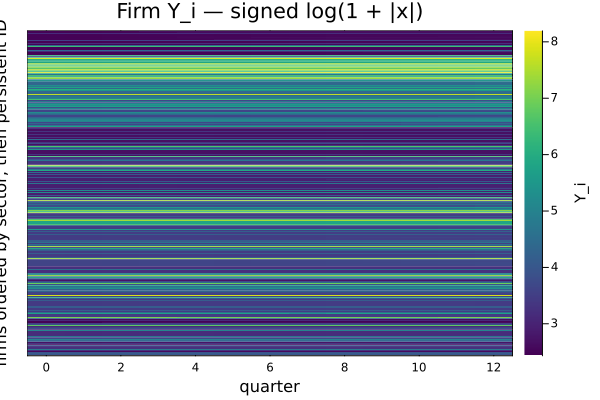

In [5]:
function observed_limits(values)
    observed = filter(isfinite, vec(values))
    isempty(observed) && error("Heatmap has no finite values")
    low, high = extrema(observed)
    margin = low == high ? max(abs(low) * 0.05, 1.0) : 0.0
    return (low - margin, high + margin)
end

function firm_heatmap(state, values; cursor = nothing, color_limits = observed_limits(values))
    chart = heatmap(
        state.quarters, collect(axes(values, 1)), values;
        xlabel = "quarter",
        ylabel = "firms ordered by sector, then persistent ID",
        title = "Firm $(state.measure) — $scale_label",
        color = :viridis,
        colorbar = true,
        colorbar_title = string(state.measure),
        clims = color_limits,
        background_color_inside = :lightgray,
        yflip = true,
        yticks = false,
        legend = false,
    )
    boundaries = [
        row for row in 1:(length(state.sectors) - 1)
        if state.sectors[row] != state.sectors[row + 1]
    ]
    isempty(boundaries) || hline!(chart, boundaries .+ 0.5; color = :white, alpha = 0.35, linewidth = 0.5, label = false)
    isnothing(cursor) || vline!(chart, [cursor]; color = :red, linewidth = 2, label = false)
    return chart
end

firm_heatmap(firm_state, heatmap_values)

## Connect firm behavior to an emergent outcome

The panels share the quarter axis. This does not establish causality, but it makes the timing of micro-level coordination and aggregate movement directly inspectable.

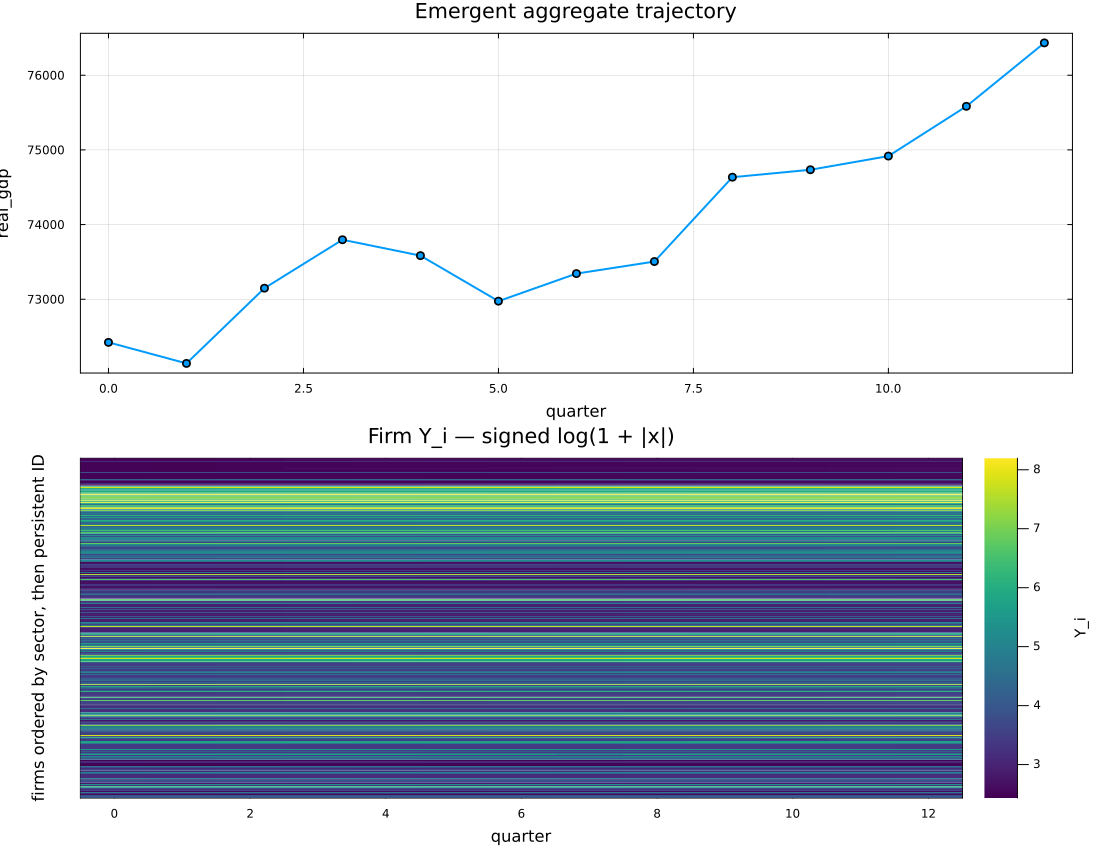

In [6]:
aggregate_field = :real_gdp
aggregate = aggregate_series(paths, aggregate_field)
aggregate_plot = plot(
    aggregate.quarter, aggregate.value;
    marker = :circle,
    xlabel = "quarter",
    ylabel = string(aggregate_field),
    title = "Emergent aggregate trajectory",
    label = false,
)
plot(aggregate_plot, firm_heatmap(firm_state, heatmap_values); layout = (2, 1), size = (1100, 850))

## Time-flowing view

The animation progressively reveals the same matrix. Future quarters remain blank, while a shared red marker moves through the aggregate trajectory and firm heatmap.

[ Info: Saved animation to /Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1/derived/baseline-seed-4101-Y_i-heatmap.gif


Plots.AnimatedGif("/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/machine-learning/explanation-traces/experiments/credit-constraint-quarterly-states-v1/derived/baseline-seed-4101-Y_i-heatmap.gif")
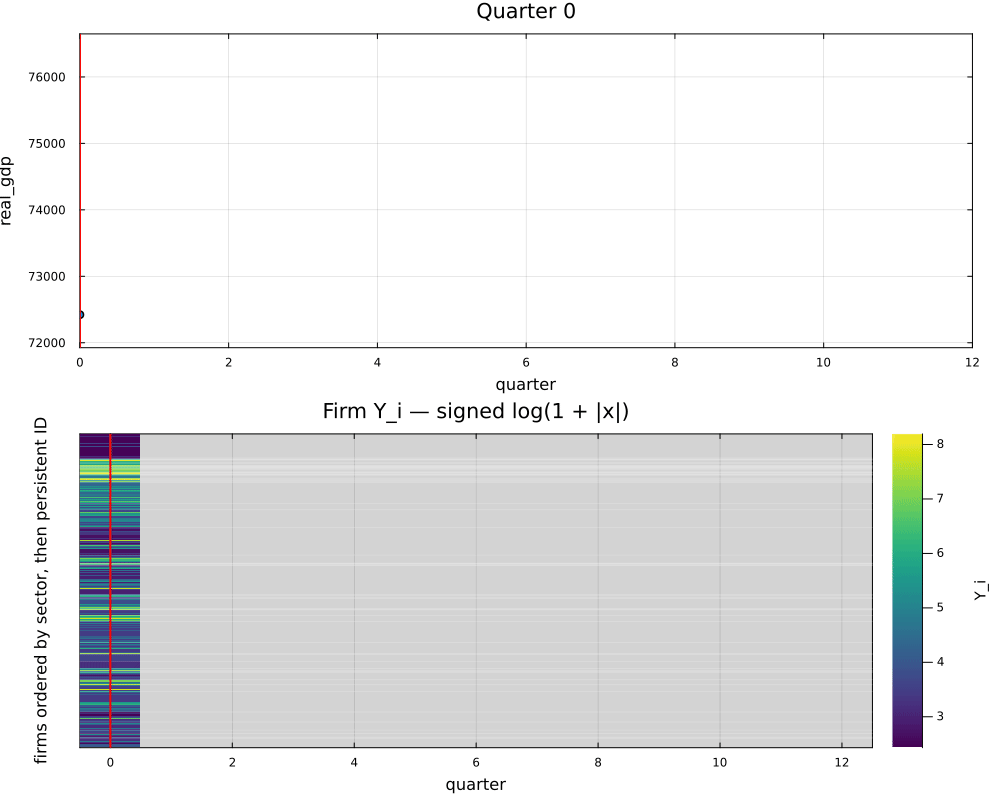

In [7]:
function flowing_heatmap(state, values, aggregate; fps = 2, output_path = tempname() * ".gif")
    color_limits = observed_limits(values)
    aggregate_low, aggregate_high = extrema(aggregate.value)
    aggregate_margin = max((aggregate_high - aggregate_low) * 0.05, 1.0)
    aggregate_limits = (aggregate_low - aggregate_margin, aggregate_high + aggregate_margin)
    animation = @animate for column in eachindex(state.quarters)
        visible = fill(NaN, size(values))
        visible[:, 1:column] .= values[:, 1:column]
        quarter = state.quarters[column]
        top = plot(
            aggregate.quarter[1:column], aggregate.value[1:column];
            marker = :circle, xlabel = "quarter", ylabel = string(aggregate_field),
            title = "Quarter $quarter", label = false,
            xlims = extrema(aggregate.quarter), ylims = aggregate_limits,
        )
        vline!(top, [quarter]; color = :red, linewidth = 2, label = false)
        bottom = firm_heatmap(state, visible; cursor = quarter, color_limits)
        plot(top, bottom; layout = (2, 1), size = (1000, 800))
    end
    return gif(animation, output_path; fps)
end

animation_directory = joinpath(experiment_directory, "derived")
mkpath(animation_directory)
animation_path = joinpath(animation_directory, "$(selected_run_id)-$(measure)-heatmap.gif")
flowing_heatmap(firm_state, heatmap_values, aggregate; output_path = animation_path)

## Reuse the same pipeline

Change only `measure` and rerun from **Build the firm-by-quarter matrix**. Useful first comparisons are `:N_i` for employment, `:Pi_i` for profit, `:E_i` for distress, and `:credit_gap` for rationing. Use one measure per heatmap so color retains a clear meaning.

In [8]:
DataFrame(
    run_id = runs.run_id,
    scenario = runs.scenario_id,
    seed = runs.seed,
    quarters = runs.snapshots_written,
    storage_mib = round.(runs.total_bytes ./ 1024^2; digits = 2),
    runtime_seconds = round.(runs.runtime_seconds; digits = 2),
    success = runs.success,
)

Row,run_id,scenario,seed,quarters,storage_mib,runtime_seconds,success
,String,String,Int64,Int64,Float64,Float64,Bool
1,baseline-seed-4101,baseline,4101,13,11.99,3.82,true
2,tighter-firm-loan-to-value-limit-seed-4101,tighter-firm-loan-to-value-limit,4101,13,12.0,0.61,true
3,baseline-seed-4102,baseline,4102,13,11.99,0.42,true
4,tighter-firm-loan-to-value-limit-seed-4102,tighter-firm-loan-to-value-limit,4102,13,12.0,0.49,true
5,baseline-seed-4103,baseline,4103,13,11.99,0.4,true
6,tighter-firm-loan-to-value-limit-seed-4103,tighter-firm-loan-to-value-limit,4103,13,12.0,0.5,true
